# Iris Flower Classification

## Machine Learning Classification Project

**Objective:**  
To train machine learning classification models to identify the species of an iris flower based on its physical measurements.

### Dataset
Iris Dataset from Scikit-learn

### Models Used
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
iris = load_iris()

print("Iris dataset loaded successfully!")

Iris dataset loaded successfully!


In [3]:
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


In [4]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


0 = Setosa
1 = Versicolor
2 = Virginica

In [5]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (150, 5)


In [7]:
print("Data types:")
print(df.dtypes)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
print(df["species"].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


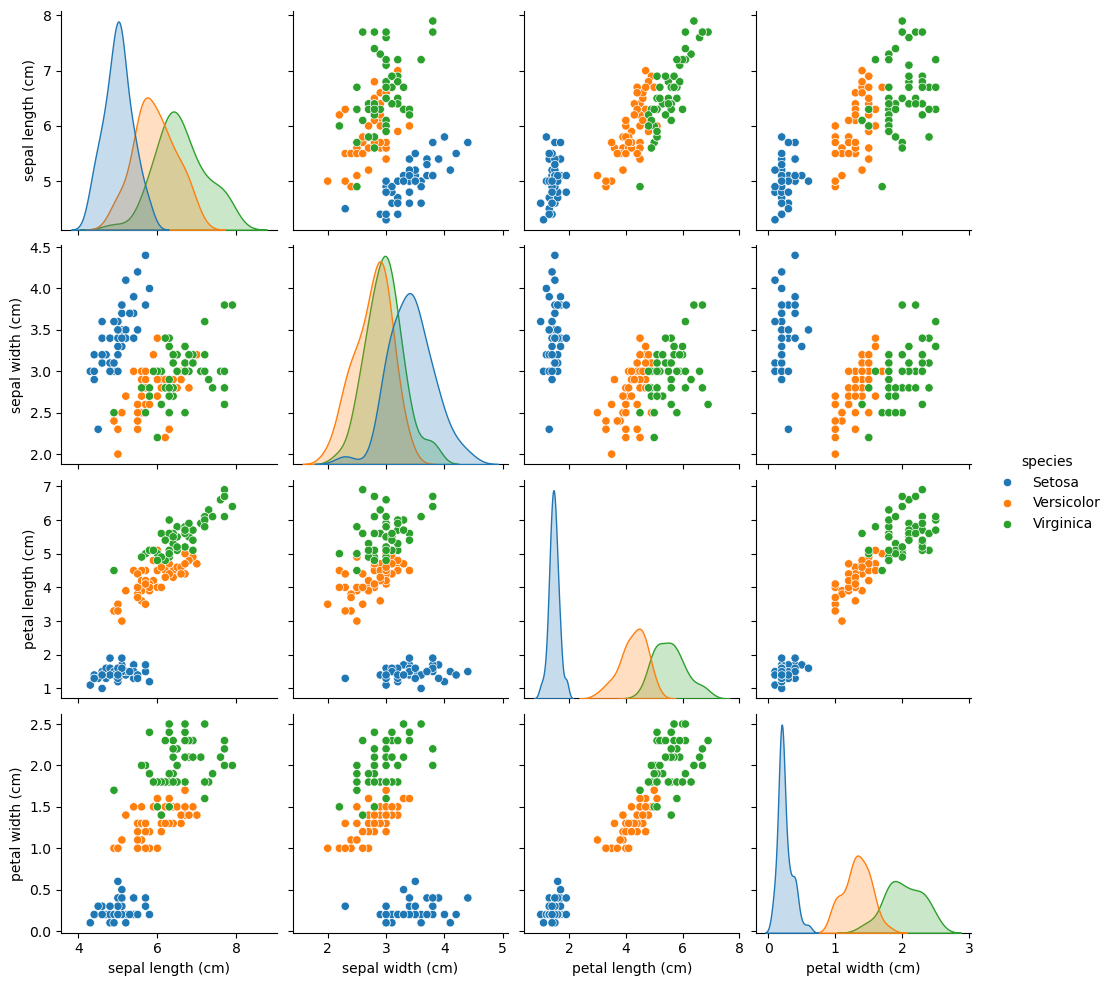

In [11]:
sns.pairplot(
    df,
    hue="species"
)

plt.show()

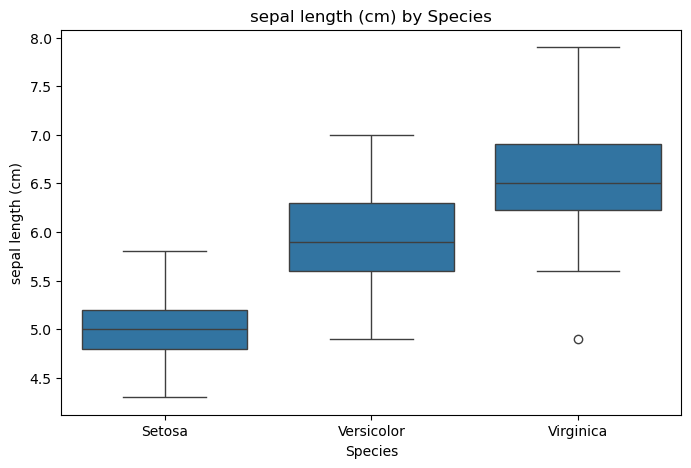

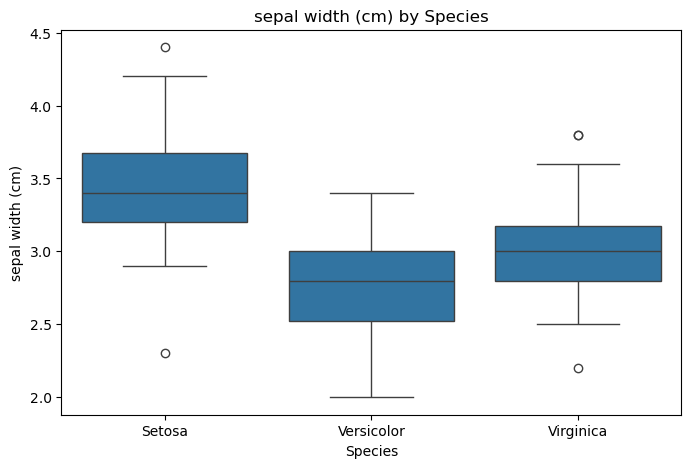

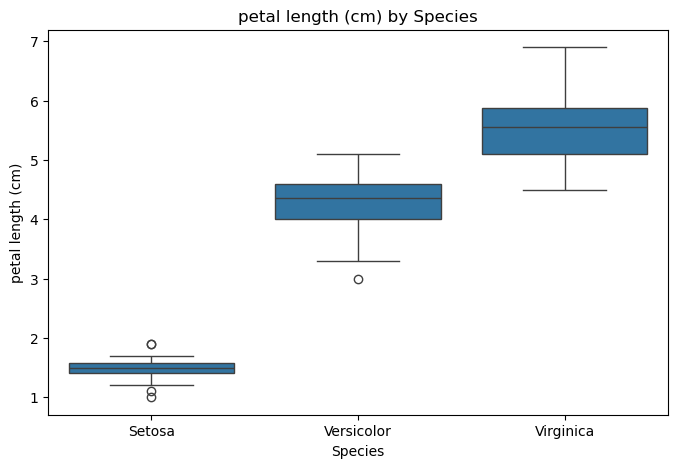

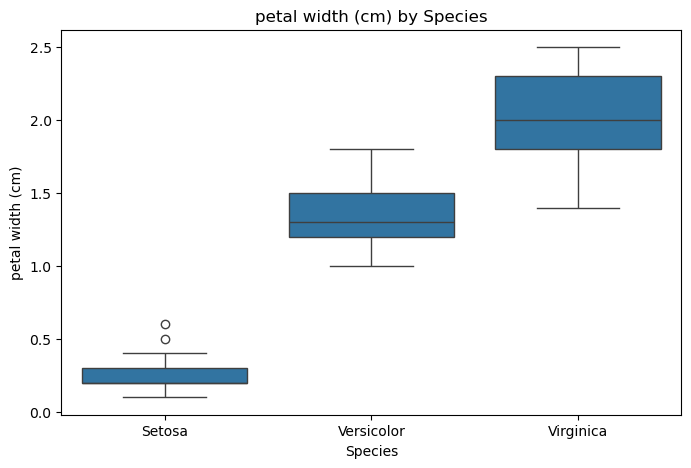

In [12]:
features = iris.feature_names

for feature in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

## Feature Selection Discussion

The Iris dataset contains four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Based on the pairplot and boxplots, **petal length and petal width are the most discriminative features**.

Setosa is clearly separated from the other two species using petal measurements. Versicolor and Virginica also show better separation using petal length and petal width compared with sepal measurements.

Therefore, petal length and petal width appear to be the most useful features for classification. However, all four features will be used for training the machine learning models so that the models can learn from the complete dataset.

In [13]:
X = df[iris.feature_names]

y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [16]:
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9333333333333333


In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9333333333333333


In [18]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.9333333333333333


In [19]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)

forest_accuracy = accuracy_score(
    y_test,
    y_pred_forest
)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 0.9


In [20]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


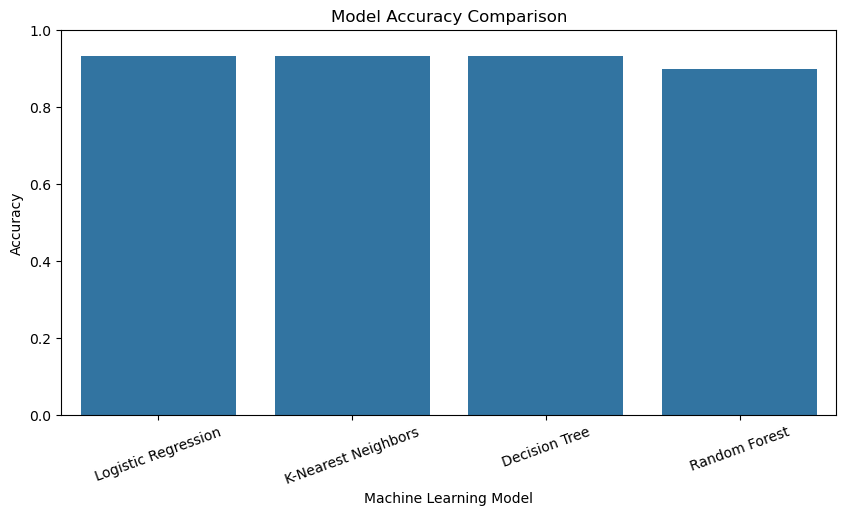

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.show()

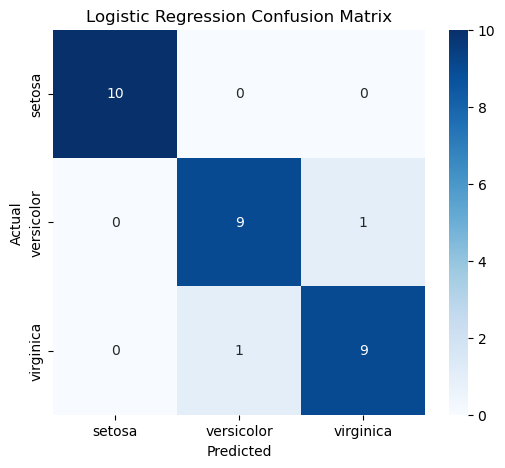

In [22]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

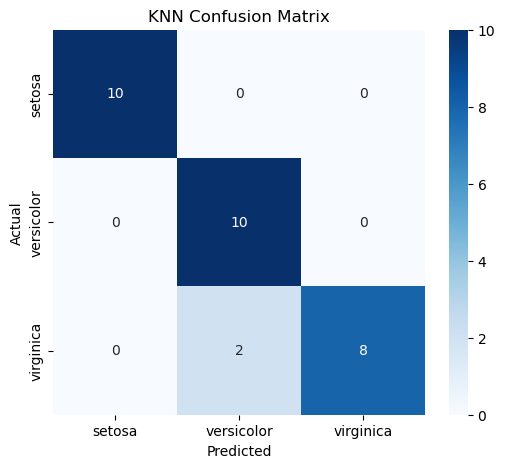

In [23]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

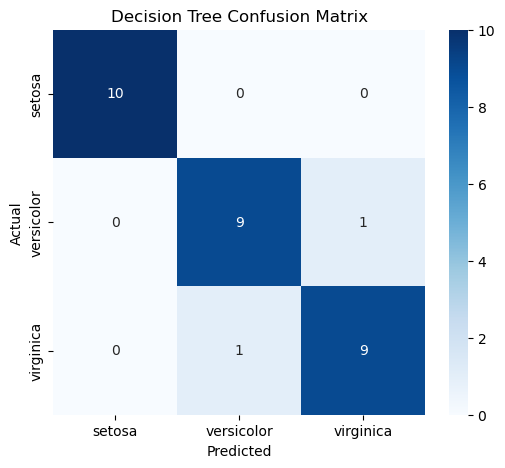

In [24]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

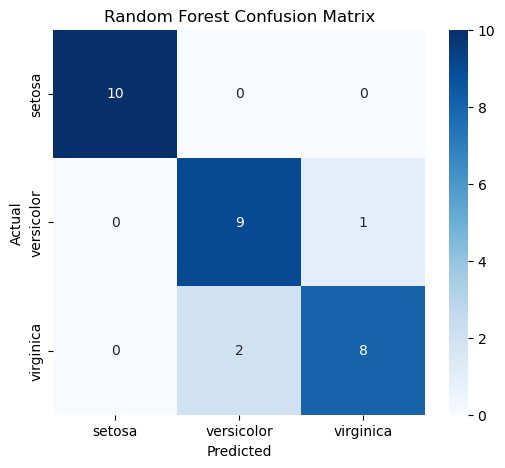

In [25]:
cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
print("===== Logistic Regression =====")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=iris.target_names
    )
)

print("===== K-Nearest Neighbors =====")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=iris.target_names
    )
)

print("===== Decision Tree =====")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=iris.target_names
    )
)

print("===== Random Forest =====")
print(
    classification_report(
        y_test,
        y_pred_forest,
        target_names=iris.target_names
    )
)

===== Logistic Regression =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

===== K-Nearest Neighbors =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

===== Decision Tree =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      

In [27]:
best_model = model_results.loc[
    model_results["Accuracy"].idxmax()
]

print("Best Performing Model:")
print("Model:", best_model["Model"])
print("Accuracy:", best_model["Accuracy"])

Best Performing Model:
Model: Logistic Regression
Accuracy: 0.9333333333333333


## Best Performing Model

The model with the highest accuracy on the test dataset is selected as the best-performing model.

The model comparison shows that the machine learning algorithms achieve high classification accuracy on the Iris dataset.

The Iris dataset is relatively simple and well-structured, with clear differences between species, especially in petal length and petal width.

The best-performing model is preferred because it provides the highest test accuracy while correctly classifying the majority of unseen test samples.

### Conclusion

Machine learning models can successfully classify Iris flowers into Setosa, Versicolor, and Virginica using their physical measurements.

Among the four features, petal length and petal width are the most discriminative features.

Several classification algorithms were trained and evaluated using accuracy, confusion matrices, precision, recall, and F1-score.

The model with the highest test accuracy was selected as the final model.

# Final Conclusion

In this project, the Iris dataset was successfully loaded from Scikit-learn without requiring an external download.

Exploratory Data Analysis was performed to understand the dataset structure, data types, missing values, descriptive statistics, and class distribution.

Visualizations such as pairplots and boxplots showed that petal length and petal width are highly useful for distinguishing between Iris species.

Four machine learning classification algorithms were trained:

1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest

The models were evaluated using accuracy, confusion matrices, precision, recall, and F1-score.

The model achieving the highest test accuracy was selected as the best-performing model.

Overall, the project demonstrates how machine learning can be used to classify flowers based on their physical characteristics.